In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib as plt

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
X = df.drop('Class', axis = 1).copy()
y = df['Class'].copy()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify = y)

In [5]:
clf_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    seed=42,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    scale_pos_weight=577,   
    base_score=0.5,         
    learning_rate=0.1,      
    n_estimators=500,       
)


In [6]:
clf_xgb.fit(X_train, y_train, verbose=True, eval_set=[(X_test, y_test)])

[0]	validation_0-aucpr:0.46399
[1]	validation_0-aucpr:0.46747
[2]	validation_0-aucpr:0.47358
[3]	validation_0-aucpr:0.47276
[4]	validation_0-aucpr:0.46935
[5]	validation_0-aucpr:0.47106
[6]	validation_0-aucpr:0.59363
[7]	validation_0-aucpr:0.59115
[8]	validation_0-aucpr:0.58966
[9]	validation_0-aucpr:0.59075
[10]	validation_0-aucpr:0.59109
[11]	validation_0-aucpr:0.59030
[12]	validation_0-aucpr:0.59267
[13]	validation_0-aucpr:0.59234
[14]	validation_0-aucpr:0.59794
[15]	validation_0-aucpr:0.61836
[16]	validation_0-aucpr:0.61768
[17]	validation_0-aucpr:0.61841
[18]	validation_0-aucpr:0.61940
[19]	validation_0-aucpr:0.65798
[20]	validation_0-aucpr:0.67948
[21]	validation_0-aucpr:0.68083
[22]	validation_0-aucpr:0.68215
[23]	validation_0-aucpr:0.68343
[24]	validation_0-aucpr:0.68489
[25]	validation_0-aucpr:0.68663
[26]	validation_0-aucpr:0.68935
[27]	validation_0-aucpr:0.69051
[28]	validation_0-aucpr:0.69293
[29]	validation_0-aucpr:0.69519
[30]	validation_0-aucpr:0.69662
[31]	validation_0-

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
print(clf_xgb.best_iteration)                        
print(clf_xgb.get_booster().num_boosted_rounds()) 

394
415


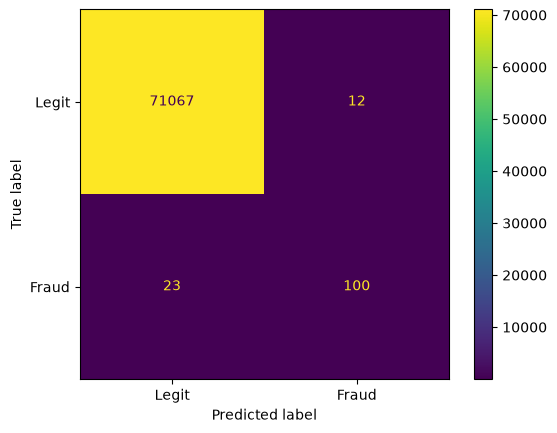

In [8]:
ConfusionMatrixDisplay.from_estimator(clf_xgb, X_test, y_test, display_labels=['Legit','Fraud'])